In [1]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Sequential = keras.models.Sequential
Dense = keras.layers.Dense
Activation = keras.layers.Activation
Dropout = keras.layers.Dropout
Flatten = keras.layers.Flatten
Conv2D = keras.layers.Conv2D
MaxPooling2D = keras.layers.MaxPooling2D

ImageDataGenerator = keras.preprocessing.image.ImageDataGenerator
EarlyStopping = keras.callbacks.EarlyStopping
optimizers = keras.optimizers

In [3]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   horizontal_flip=True,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)

In [4]:
train_generator = train_datagen.flow_from_directory(
    '../data/data-ch20-master/train',
    target_size=(150, 150),
    batch_size=5,
    class_mode='binary'
)

Found 160 images belonging to 2 classes.


In [5]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '../data/data-ch20-master/test',
    target_size=(150, 150),
    batch_size=5,
    class_mode='binary'
)

Found 120 images belonging to 2 classes.


In [6]:
model = Sequential()
model.add(Conv2D(32, (3,3), input_shape=(150,150,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.summary()

/home/kth/anaconda3/envs/dl_venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1747638511.727991   53197 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1747638511.771489   53197 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1747638511.771854   5

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 72, 72, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,212,513 (4.63 MB)

 Trainable params: 1,212,513 (4.63 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.Adam(learning_rate=0.0002),
              metrics=['accuracy'])

In [8]:
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=test_generator,
    validation_steps=10
)

Epoch 1/100


/home/kth/anaconda3/envs/dl_venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1747638658.810003   56388 service.cc:146] XLA service 0x7c23d40045f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747638658.810027   56388 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2025-05-19 16:10:58.836557: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-19 16:10:58.990718: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90101


11/32 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5331 - loss: 0.7003

I0000 00:00:1747638660.526829   56388 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5171 - loss: 0.6981

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9905 - loss: 0.0265 - val_accuracy: 1.0000 - val_loss: 0.0257
Epoch 95/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9801 - loss: 0.0862 - val_accuracy: 1.0000 - val_loss: 0.0063
Epoch 96/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9843 - loss: 0.0516 - val_accuracy: 1.0000 - val_loss: 0.0226
Epoch 97/100
 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0118

2025-05-19 16:12:03.438211: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2025-05-19 16:12:03.438251: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9485190977800413867
2025-05-19 16:12:03.438260: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9214525726436504060


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9981 - loss: 0.0151 - val_accuracy: 1.0000 - val_loss: 0.0108
Epoch 98/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.0163 - val_accuracy: 0.9200 - val_loss: 0.1785
Epoch 99/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9974 - loss: 0.0125 - val_accuracy: 1.0000 - val_loss: 0.0107
Epoch 100/100
 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9545 - loss: 0.2155

2025-05-19 16:12:05.411862: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9485190977800413867
2025-05-19 16:12:05.411895: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9214525726436504060


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9731 - loss: 0.1090 - val_accuracy: 1.0000 - val_loss: 0.0041


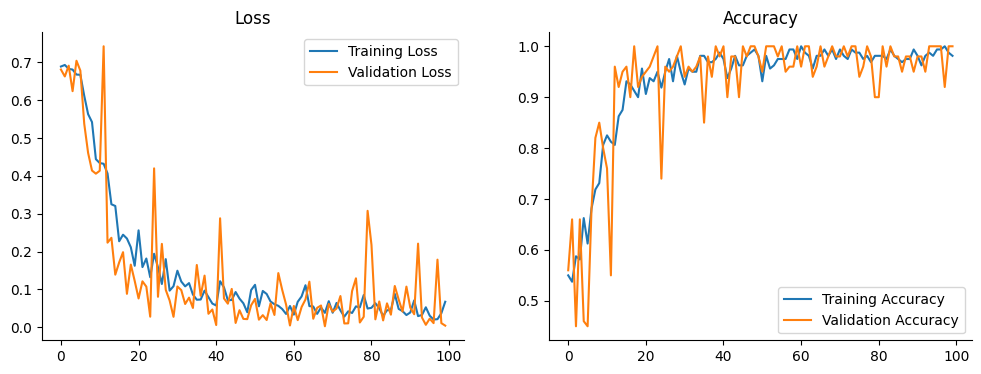

In [9]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(x=range(len(history.history["loss"])),
             y=history.history["loss"], ax=axes[0],
             label="Training Loss")
sns.lineplot(x=range(len(history.history["loss"])),
             y=history.history["val_loss"], ax=axes[0],
             label="Validation Loss")

sns.lineplot(x=range(len(history.history["accuracy"])),
             y=history.history["accuracy"], ax=axes[1],
             label="Training Accuracy")
sns.lineplot(x=range(len(history.history["accuracy"])),
             y=history.history["val_accuracy"], ax=axes[1],
             label="Validation Accuracy")
axes[0].set_title("Loss")
axes[1].set_title("Accuracy")

sns.despine()
plt.show()

In [10]:
VGG16 = keras.applications.VGG16
Input = keras.Input

In [11]:
transfer_model = VGG16(weights='imagenet', include_top=False,
                       input_shape=(150, 150, 3))
transfer_model.trainable = False
transfer_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
GlobalAveragePooling2D = keras.layers.GlobalAveragePooling2D
import tensorflow as tf

def vgg16_pretrained():
    inputs = Input(shape=(150, 150, 3))
    x = transfer_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dense(100, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    return model

In [13]:
finetune_model = vgg16_pretrained()
finetune_model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,772,517 (56.35 MB)

 Trainable params: 57,829 (225.89 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
finetune_model.compile(optimizer=optimizers.Adam(learning_rate=0.0002),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

In [15]:
history = finetune_model.fit(
    train_generator,
    epochs=100,
    validation_data=test_generator,
    validation_steps=10
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.5143 - loss: 0.7284 - val_accuracy: 0.6000 - val_loss: 0.6587
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5861 - loss: 0.6566 - val_accuracy: 0.4600 - val_loss: 0.6783
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5609 - loss: 0.6744 - val_accuracy: 0.6500 - val_loss: 0.6318
Epoch 4/100
 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5939 - loss: 0.6452

2025-05-19 17:00:40.673725: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9485190977800413867
/home/kth/anaconda3/envs/dl_venv/lib/python3.12/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)
2025-05-19 17:00:40.673759: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9214525726436504060


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6389 - loss: 0.6404 - val_accuracy: 0.8600 - val_loss: 0.6284
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6145 - loss: 0.6458 - val_accuracy: 0.8000 - val_loss: 0.5756
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6678 - loss: 0.6178 - val_accuracy: 0.7500 - val_loss: 0.6008
Epoch 7/100
 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6241 - loss: 0.5941

2025-05-19 17:00:42.956268: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9485190977800413867
2025-05-19 17:00:42.956304: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9214525726436504060


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7042 - loss: 0.5898 - val_accuracy: 0.9000 - val_loss: 0.5380
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6026 - loss: 0.6289 - val_accuracy: 0.8200 - val_loss: 0.5408
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7117 - loss: 0.5600 - val_accuracy: 0.8500 - val_loss: 0.5447
Epoch 10/100
 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6058 - loss: 0.6330

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9803 - loss: 0.0612 - val_accuracy: 0.9600 - val_loss: 0.0990
Epoch 92/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9799 - loss: 0.0696 - val_accuracy: 0.9600 - val_loss: 0.1310
Epoch 93/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9515 - loss: 0.1167 - val_accuracy: 1.0000 - val_loss: 0.0616
Epoch 94/100
 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8947 - loss: 0.2354

2025-05-19 17:01:50.259868: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2025-05-19 17:01:50.259896: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9485190977800413867
2025-05-19 17:01:50.259914: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9214525726436504060


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9504 - loss: 0.1266 - val_accuracy: 1.0000 - val_loss: 0.0435
Epoch 95/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9675 - loss: 0.1142 - val_accuracy: 0.9800 - val_loss: 0.0768
Epoch 96/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9744 - loss: 0.0771 - val_accuracy: 0.9500 - val_loss: 0.1413
Epoch 97/100
 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9959 - loss: 0.0737

2025-05-19 17:01:52.579062: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9485190977800413867
2025-05-19 17:01:52.579098: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9214525726436504060


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9704 - loss: 0.0824 - val_accuracy: 0.9600 - val_loss: 0.1330
Epoch 98/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9546 - loss: 0.1294 - val_accuracy: 0.9000 - val_loss: 0.2315
Epoch 99/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9662 - loss: 0.0820 - val_accuracy: 0.9000 - val_loss: 0.1302
Epoch 100/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9802 - loss: 0.0662 - val_accuracy: 0.9200 - val_loss: 0.2312


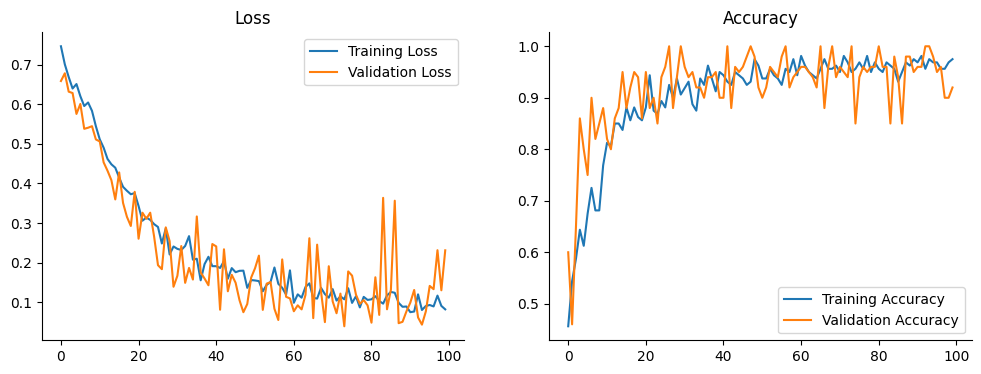

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(x=range(len(history.history["loss"])),
             y=history.history["loss"], ax=axes[0],
             label="Training Loss")
sns.lineplot(x=range(len(history.history["loss"])),
             y=history.history["val_loss"], ax=axes[0],
             label="Validation Loss")

sns.lineplot(x=range(len(history.history["accuracy"])),
             y=history.history["accuracy"], ax=axes[1],
             label="Training Accuracy")
sns.lineplot(x=range(len(history.history["accuracy"])),
             y=history.history["val_accuracy"], ax=axes[1],
             label="Validation Accuracy")
axes[0].set_title("Loss")
axes[1].set_title("Accuracy")

sns.despine()
plt.show()